# 🏥 Healthcare Fraud Detection - FYP Final
**Final Year Project - 7 Models Comparison**

**Objective:** Compare 7 ML models and identify the best one for detecting fraudulent healthcare claims

---

## 📦 Step 1: Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

print("FYP FRAUD DETECTION - 7 MODELS")
print("="*70)

FYP FRAUD DETECTION - 7 MODELS


## 📊 Step 2: Load Dataset

In [32]:
# Auto-detect CSV file
csv_files = glob.glob('*.csv')
data = pd.read_csv(csv_files[0])

print(f"Loaded: {csv_files[0]} | Shape: {data.shape}")

Loaded: simulated_healthcare_claims (1).csv | Shape: (20000, 8)


## 🔧 Step 3: Feature Engineering

In [33]:
# Create binary fraud target
data['FraudStatus'] = (data['Fraud Type'] != 'No Fraud').astype(int)

# Process dates
data['Date Admitted'] = pd.to_datetime(data['Date Admitted'], errors='coerce')
data['Date Discharged'] = pd.to_datetime(data['Date Discharged'], errors='coerce')

# Calculate stay duration
data['StayDuration'] = (data['Date Discharged'] - data['Date Admitted']).dt.days.fillna(1).clip(lower=0)

# Drop unnecessary columns
cols_to_drop = ['Patient ID', 'Date Admitted', 'Date Discharged', 'Fraud Type']
data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

print(f"Features created successfully!")

Features created successfully!


## 🔄 Step 4: Data Preprocessing

### 4.1: Split Data

In [34]:
# Separate features and target
X = data.drop('FraudStatus', axis=1)
y = data['FraudStatus']

# Train-test split (25% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (15000, 5), Test: (5000, 5)


### 4.2: One-Hot Encoding (Fixed)

In [35]:
# One-hot encode categorical variables
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# FIXED: Align columns between train and test
all_cols = list(set(X_train_enc.columns).union(set(X_test_enc.columns)))
X_train_enc = X_train_enc.reindex(columns=all_cols, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=all_cols, fill_value=0)

# Clean NaN values
X_train_enc = X_train_enc.fillna(0)
X_test_enc = X_test_enc.fillna(0)

print(f"Encoded - Train: {X_train_enc.shape}, Test: {X_test_enc.shape}")

Encoded - Train: (15000, 13), Test: (5000, 13)


### 4.3: Feature Scaling

In [36]:
# Standardize features for distance-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print(f"Scaling complete!")

Scaling complete!


## 🤖 Step 5: Model Training Function

In [37]:
def test_model(model, name, scaled=False):
    """
    Train and evaluate a model

    Parameters:
    - model: ML model to train
    - name: Model name
    - scaled: Use scaled data (True for SVC, KNN)

    Returns:
    - Dictionary with results
    """
    try:
        X_tr = X_train_scaled if scaled else X_train_enc
        X_te = X_test_scaled if scaled else X_test_enc
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        return {'name': name, 'acc': acc, 'f1': f1, 'pred': y_pred, 'model': model}
    except:
        return {'name': name, 'acc': 0, 'f1': 0, 'pred': None, 'model': None}

print("Model testing function defined")

Model testing function defined


## 🏆 Step 6: Train 7 Models

Testing:
1. Logistic Regression
2. SVC
3. KNN
4. Decision Tree
5. Random Forest
6. Gradient Boosting
7. Voting Ensemble

In [38]:
print("\nTESTING 7 MODELS:")
print("-"*50)

models = [
    (LogisticRegression(class_weight='balanced', max_iter=1000), "Logistic", False),
    (SVC(class_weight='balanced', probability=True), "SVC", True),
    (KNeighborsClassifier(n_neighbors=30), "KNN", True),
    (DecisionTreeClassifier(class_weight='balanced'), "Decision Tree", False),
    (RandomForestClassifier(n_estimators=100, class_weight='balanced'), "Random Forest", False),
    (GradientBoostingClassifier(n_estimators=50), "Gradient Boosting", False),
    (VotingClassifier([('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced')),
                      ('gb', GradientBoostingClassifier(n_estimators=100)),
                      ('dt', DecisionTreeClassifier(class_weight='balanced'))], voting='soft'), "Voting Ensemble", False)
]

results = []
for model, name, scaled in models:
    result = test_model(model, name, scaled)
    print(f"{name:20} | Acc: {result['acc']:.3f} | F1: {result['f1']:.3f}")
    results.append(result)


TESTING 7 MODELS:
--------------------------------------------------
Logistic             | Acc: 0.781 | F1: 0.657
SVC                  | Acc: 0.850 | F1: 0.726
KNN                  | Acc: 0.805 | F1: 0.582
Decision Tree        | Acc: 0.778 | F1: 0.636
Random Forest        | Acc: 0.848 | F1: 0.708
Gradient Boosting    | Acc: 0.863 | F1: 0.744
Voting Ensemble      | Acc: 0.839 | F1: 0.695


## 🎯 Step 7: Best Model Selection

In [39]:
# Select best model by F1 score
valid_results = [r for r in results if r['f1'] > 0]
best = max(valid_results, key=lambda x: x['f1']) if valid_results else results[0]

print("\n" + "="*70)
print("FINAL BEST MODEL FOR FYP REPORT")
print("="*70)
print(f"BEST MODEL: {best['name']}")
print(f"TEST ACCURACY:  {best['acc']:.4f}")
print(f"F1 FRAUD CLASS: {best['f1']:.4f}")
print("="*70)


FINAL BEST MODEL FOR FYP REPORT
BEST MODEL: Gradient Boosting
TEST ACCURACY:  0.8634
F1 FRAUD CLASS: 0.7437


## 📊 Step 8: Detailed Metrics

In [40]:
if best['pred'] is not None:
    cm = confusion_matrix(y_test, best['pred'])
    report = classification_report(y_test, best['pred'], output_dict=True)

    print("\nCONFUSION MATRIX:")
    print("                  PREDICTED")
    print("                Genuine    Fraud")
    print(f"TRUE Genuine   {cm[0,0]:4d}     {cm[0,1]:4d}")
    print(f"TRUE Fraud     {cm[1,0]:4d}     {cm[1,1]:4d}")

    print(f"\nMETRICS (FRAUD CLASS):")
    print(f"Precision: {report['1']['precision']:.3f}")
    print(f"Recall:    {report['1']['recall']:.3f}")
    print(f"F1-Score:  {report['1']['f1-score']:.3f}")


CONFUSION MATRIX:
                  PREDICTED
                Genuine    Fraud
TRUE Genuine   3326      194
TRUE Fraud      489      991

METRICS (FRAUD CLASS):
Precision: 0.836
Recall:    0.670
F1-Score:  0.744


## 📈 Step 9: FYP Visualizations


TOP 5 FEATURES:
               feature  importance
         Amount Billed       0.790
   Diagnosis_Pregnancy       0.137
           Gender_Male       0.063
                   Age       0.007
Diagnosis_Hypertension       0.001


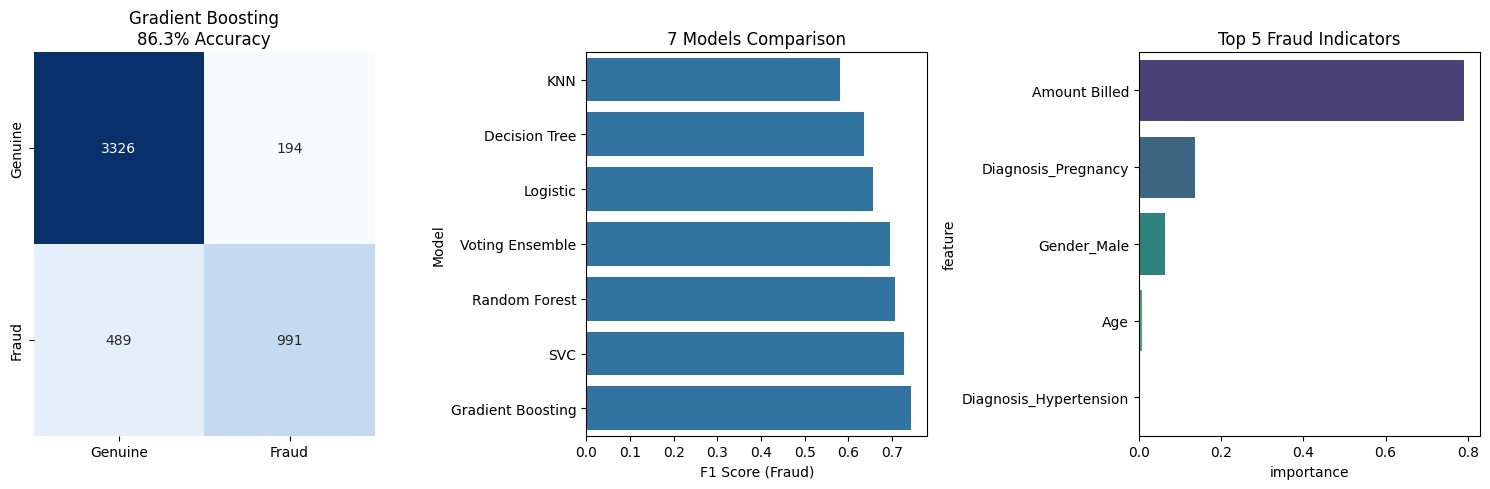

In [41]:
if best['pred'] is not None:
    plt.figure(figsize=(15, 5))

    # Plot 1: Confusion Matrix
    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
    plt.title(f'{best["name"]}\n{best["acc"]:.1%} Accuracy', fontsize=12)

    # Plot 2: Model Comparison
    plt.subplot(1, 3, 2)
    results_df = pd.DataFrame([{'Model': r['name'], 'F1': r['f1']} for r in results])
    sns.barplot(data=results_df.sort_values('F1', ascending=True), y='Model', x='F1')
    plt.title('7 Models Comparison')
    plt.xlabel('F1 Score (Fraud)')

    # Plot 3: Feature Importance (if available)
    if hasattr(best['model'], 'feature_importances_'):
        fi = pd.DataFrame({
            'feature': X_train_enc.columns,
            'importance': best['model'].feature_importances_
        }).nlargest(5, 'importance')
        plt.subplot(1, 3, 3)
        sns.barplot(data=fi, x='importance', y='feature', palette='viridis')
        plt.title('Top 5 Fraud Indicators')
        print(f"\nTOP 5 FEATURES:")
        print(fi.round(3).to_string(index=False))

    plt.tight_layout()
    plt.show()

## ✅ Step 10: Final Summary

In [42]:
print("\n" + "="*70)
print("FYP COMPLETE!")
print(f"DEPLOY: '{best['name']}'")
print(f"RESULTS: {best['acc']:.1%} acc, {best['f1']:.1%} F1")
print("="*70)


FYP COMPLETE!
DEPLOY: 'Gradient Boosting'
RESULTS: 86.3% acc, 74.4% F1
